# 01 数据探索
探索 RAVDESS 和 CASIA 数据集的基本统计信息、音频时长分布、情感类别分布等。

In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd

# 自动查找项目根目录（兼容从任意目录启动 Jupyter）
for _candidate in [os.path.abspath('..'), os.path.abspath('.'), os.path.expanduser('~/identifier')]:
    if os.path.isfile(os.path.join(_candidate, 'configs', 'config.yaml')):
        PROJECT_ROOT = _candidate
        break
else:
    raise RuntimeError('找不到项目根目录，请确认 configs/config.yaml 存在')
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
print(f'项目根目录: {PROJECT_ROOT}')

from utils.audio_utils import load_config, EMOTION_LABELS, LABEL2ID, EMOTION_NAMES_ZH

cfg = load_config()
print('配置加载完成')

项目根目录: /root/identifier
配置加载完成


## 1. 扫描数据集

In [2]:
def scan_dataset(root_dir):
    """扫描目录，返回 DataFrame (path, emotion, duration)。"""
    records = []
    for label in sorted(os.listdir(root_dir)):
        label_dir = os.path.join(root_dir, label)
        if not os.path.isdir(label_dir) or label not in LABEL2ID:
            continue
        for wav in glob.glob(os.path.join(label_dir, '*.wav')):
            try:
                dur = librosa.get_duration(path=wav)
                records.append({'path': wav, 'emotion': label, 'duration': dur})
            except Exception as e:
                print(f'跳过 {wav}: {e}')
    return pd.DataFrame(records)

processed_dir = cfg['paths']['processed_data']
dfs = {}
for subset in ('ravdess', 'casia'):
    d = os.path.join(processed_dir, subset)
    if os.path.isdir(d):
        dfs[subset] = scan_dataset(d)
        print(f'{subset}: {len(dfs[subset])} 个样本')

if dfs:
    df_all = pd.concat(dfs.values(), ignore_index=True)
    print(f'\n总计: {len(df_all)} 个样本')
else:
    print('未找到预处理数据，请先运行 preprocessing/audio_preprocess.py')

ravdess: 1440 个样本

总计: 1440 个样本


## 2. 情感类别分布

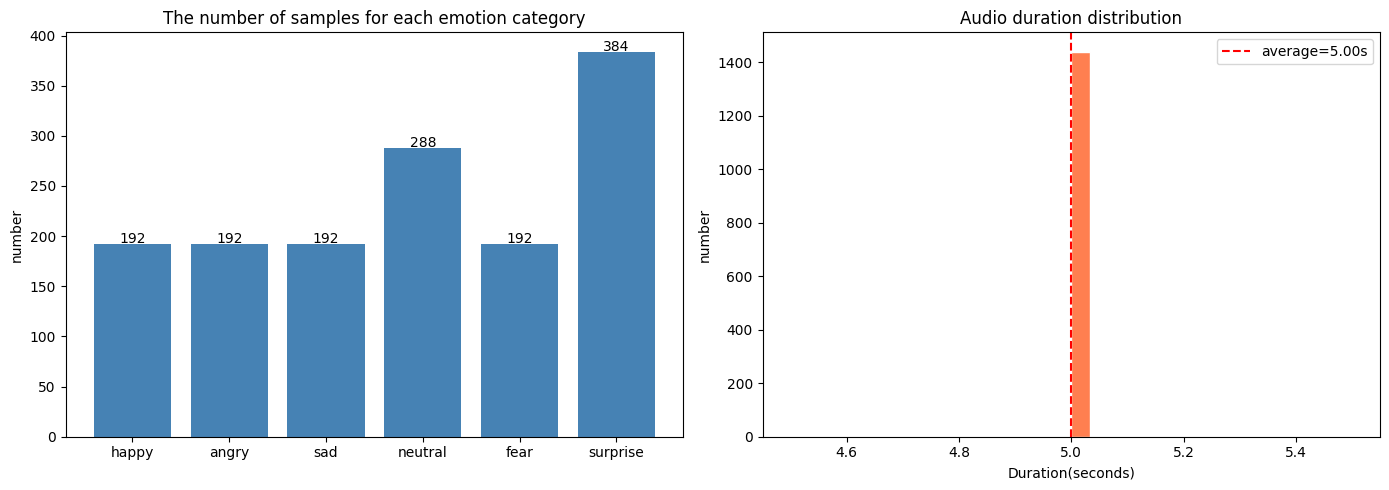

In [3]:
if 'df_all' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 类别分布柱状图
    counts = df_all['emotion'].value_counts().reindex(EMOTION_LABELS)
    axes[0].bar(EMOTION_LABELS, counts.values, color='steelblue')
    axes[0].set_title('The number of samples for each emotion category')
    axes[0].set_ylabel('number')
    for i, v in enumerate(counts.values):
        axes[0].text(i, v + 1, str(v), ha='center')
    
    # 时长分布直方图
    axes[1].hist(df_all['duration'], bins=30, color='coral', edgecolor='white')
    axes[1].set_title('Audio duration distribution')
    axes[1].set_xlabel('Duration(seconds)')
    axes[1].set_ylabel('number')
    axes[1].axvline(df_all['duration'].mean(), color='red', linestyle='--',
                    label=f'average={df_all["duration"].mean():.2f}s')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

## 3. 随机播放样本


情感: 高兴 (happy), 时长: 5.00s


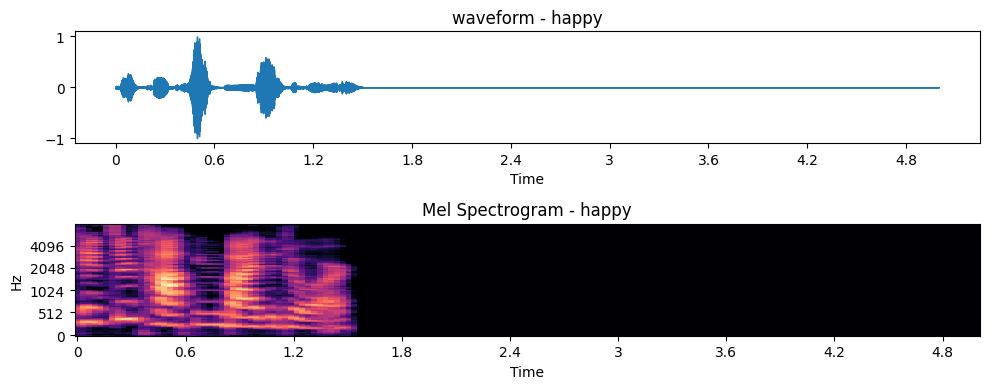


情感: 愤怒 (angry), 时长: 5.00s


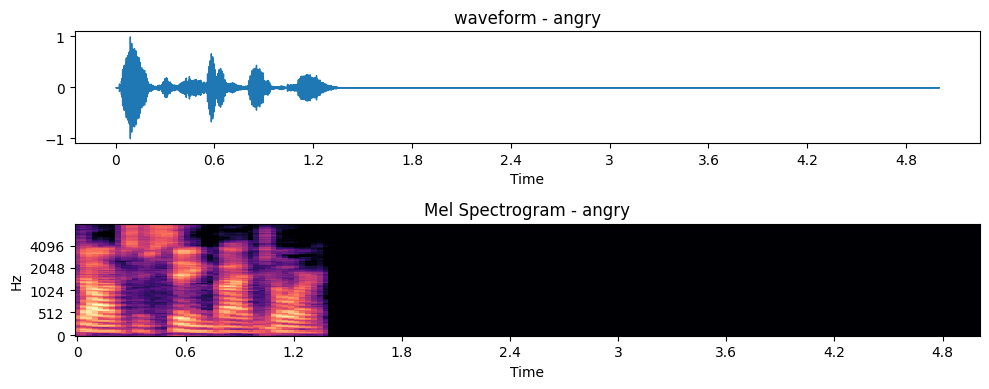


情感: 悲伤 (sad), 时长: 5.00s


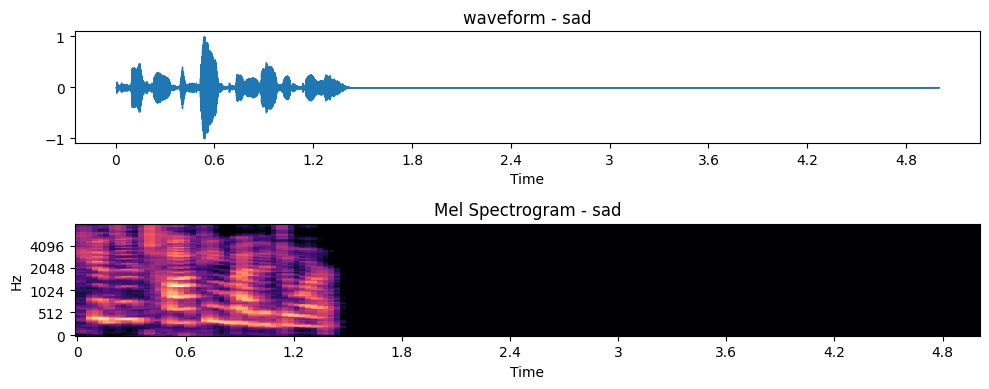

In [4]:
if 'df_all' in dir():
    for emotion in EMOTION_LABELS[:3]:
        subset = df_all[df_all['emotion'] == emotion]
        if len(subset) == 0:
            continue
        sample = subset.sample(1).iloc[0]
        print(f'\n情感: {EMOTION_NAMES_ZH[emotion]} ({emotion}), 时长: {sample["duration"]:.2f}s')
        audio, sr = librosa.load(sample['path'], sr=16000)
        ipd.display(ipd.Audio(audio, rate=sr))
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4))
        librosa.display.waveshow(audio, sr=sr, ax=ax1)
        ax1.set_title(f'waveform - {emotion}')
        mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
        librosa.display.specshow(librosa.power_to_db(mel, ref=np.max),
                                 sr=sr, x_axis='time', y_axis='mel', ax=ax2, cmap='magma')
        ax2.set_title(f'Mel Spectrogram - {emotion}')
        plt.tight_layout()
        plt.show()